In [34]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import mlxtend

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score
from sklearn.linear_model import LogisticRegression

In [2]:
print("Hello")

Hello


Implement Gaussian Naive Bayes classification.
Download and read dataset iris.csv. Import necessary files to implement
Gaussian Naive Bayes classification. Perform Label encoding with required
columns. Implement Gaussian Naive Bayes classification. Print confusion
matrix and classification report.

In [5]:
df = pd.read_csv("iris.csv")
print(df.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [7]:
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

In [8]:
X = df.drop('Species', axis=1)  
y = df['Species']  

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [11]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [12]:
report = classification_report(y_test, y_pred)
print("\nClassification Report:\n", report)


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Classify data with KNN algorithm.

Implement the algorithm with the help of the 'mobile.csv' dataset. Visualize
purchased and not_purchased data distribution based on age and estimated
salary using a scatter plot. Apply MinMaxScaler to the dataset. Predict if the
customer will purchase a mobile or not.

In [14]:
df = pd.read_csv("mobile.csv")
print(df.head())

   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0


In [15]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

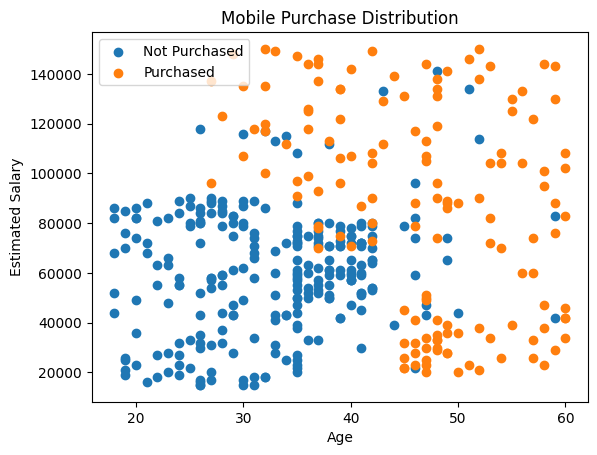

In [16]:
plt.figure()

plt.scatter(
    X[y == 0]['Age'],
    X[y == 0]['EstimatedSalary']
)

plt.scatter(
    X[y == 1]['Age'],
    X[y == 1]['EstimatedSalary']
)

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Mobile Purchase Distribution")
plt.legend(["Not Purchased", "Purchased"])
plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [20]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[48  4]
 [ 2 26]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94        52
           1       0.87      0.93      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80



In [21]:
new_data = [[40, 60000]]
new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)

if prediction[0] == 1:
    print("Customer will PURCHASE the mobile")
else:
    print("Customer will NOT PURCHASE the mobile")

Customer will NOT PURCHASE the mobile


C:\Users\rs889\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


 Develop Simple Linear Regression.

Develop Simple Linear Regression with help of computer.csv dataset. Fit the
model with the data and fetching intercept and coefficient. Visualize Models
using pyplot. Compute the Coefficient of Determination to find accuracy.

In [24]:
df = pd.read_csv("computers.csv")
print(df.head())
print(df.columns)   

   Units  Minutes
0      1       23
1      2       29
2      3       49
3      4       64
4      4       74
Index(['Units', 'Minutes'], dtype='str')


In [27]:
X = df[['Units']]   
y = df['Minutes']     

In [29]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 4.161654135338296
Coefficient: 15.508771929824569


In [31]:
y_pred = model.predict(X)

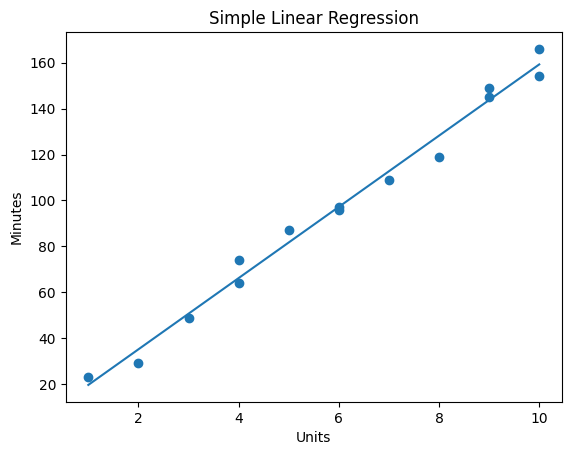

In [32]:
plt.scatter(X, y)        
plt.plot(X, y_pred)     

plt.xlabel("Units")
plt.ylabel("Minutes")
plt.title("Simple Linear Regression")
plt.show()

In [33]:
r2 = r2_score(y, y_pred)
print("R² Score:", r2)

R² Score: 0.9874371980620736


Build Logistic Regression Model.

Import chd.csv dataset and visualize the data to get an insight on building
the model. Specifying the columns as predictor and target variable. Split the
data in training and test set in 70:30 ratio. Built model using
sklearn.linear_model.LogisticRegression class. Train the model using the
training data. Fetch the intercept and the coefficients of the model. Creating
sample data. Predicting the probabilities for each of the class labels.

In [36]:
df = pd.read_csv("chd_data.csv")
print(df.head())
print(df.columns)

   age  chd
0   20    0
1   23    0
2   24    0
3   25    1
4   25    0
Index(['age', 'chd'], dtype='str')


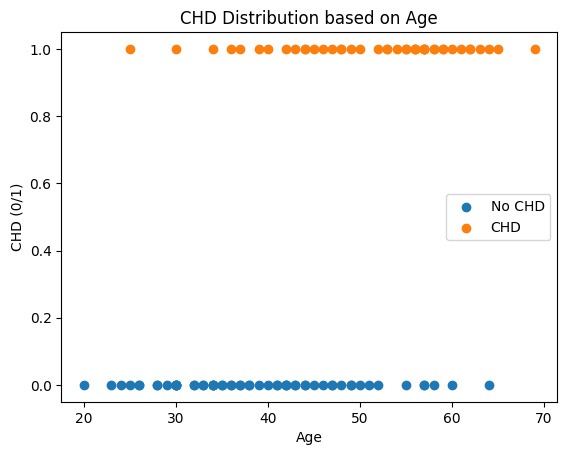

In [37]:
plt.figure()

plt.scatter(
    df[df['chd'] == 0]['age'],
    df[df['chd'] == 0]['chd']
)


plt.scatter(
    df[df['chd'] == 1]['age'],
    df[df['chd'] == 1]['chd']
)

plt.xlabel("Age")
plt.ylabel("CHD (0/1)")
plt.title("CHD Distribution based on Age")
plt.legend(["No CHD", "CHD"])
plt.show()

In [38]:
X = df[['age']]   
y = df['chd']     

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [40]:
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [41]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0][0])

Intercept: [-5.70885812]
Coefficient: 0.11832746553891965


In [42]:
y_pred = model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[14  3]
 [ 5  8]]

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.82      0.78        17
           1       0.73      0.62      0.67        13

    accuracy                           0.73        30
   macro avg       0.73      0.72      0.72        30
weighted avg       0.73      0.73      0.73        30



In [43]:
sample = np.array([[45]])

prob = model.predict_proba(sample)

print("Probability [No CHD, CHD]:", prob)

Probability [No CHD, CHD]: [[0.59486693 0.40513307]]


C:\Users\rs889\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [44]:
if prob[0][1] > 0.5:
    print("High risk of CHD")
else:
    print("Low risk of CHD")

Low risk of CHD
